In [2]:
# DAY 30 - FINDING THE IDEAL NUMBER OF CUSTOMER SEGMENTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Day 30 libraries imported successfully!")

Day 30 libraries imported successfully!


In [3]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [4]:
# Create customer-level behavior data

customer_data = df.groupby("customer_name").agg(
    total_sales=("sales", "sum"),
    total_quantity=("quantity", "sum"),
    total_profit=("profit", "sum"),
    average_discount=("discount", "mean"),
    average_shipping_days=("shipping_days", "mean"),
    number_of_orders=("order_id", "count")
).reset_index()

print("Customer-level data created successfully!")
print("Number of customers:", len(customer_data))

customer_data.head()

Customer-level data created successfully!
Number of customers: 795


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84


In [5]:
# Select customer behavior features

feature_columns = [
    "total_sales",
    "total_quantity",
    "total_profit",
    "average_discount",
    "average_shipping_days",
    "number_of_orders"
]

X = customer_data[feature_columns]

print("Customer behavior features selected successfully!")
print("\nFeatures used:")
print(feature_columns)

print("\nFeature data shape:", X.shape)

X.head()

Customer behavior features selected successfully!

Features used:
['total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders']

Feature data shape: (795, 6)


,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
0,24646.0,301,4683.20800,0.110112,3.707865,89
1,20759.0,231,2450.92904,0.160929,3.464286,56
2,14207.0,211,369.16180,0.167667,4.433333,60
3,20189.0,262,4979.97690,0.131765,3.514706,68
4,21720.0,293,1902.03342,0.093238,3.654762,84


In [6]:
# Scale customer behavior features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Customer features scaled successfully!")
print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Customer features scaled successfully!
Scaled data shape: (795, 6)

First 5 scaled rows:
[[ 1.67923479  1.51782672  1.83675336 -0.73064577 -0.72146871  1.8239146 ]
 [ 0.93267132  0.13273486  0.3906802   0.39657357 -1.38947874 -0.63436434]
 [-0.32575005 -0.26300567 -0.95789127  0.54603987  1.26810801 -0.33639113]
 [ 0.82319327  0.74613269  2.02900063 -0.2503474  -1.2512028   0.25955528]
 [ 1.11724747  1.35953051  0.03510492 -1.10495539 -0.86710297  1.45144809]]


In [7]:
# Test different numbers of clusters

cluster_results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    cluster_results.append({
        "Clusters": k,
        "Inertia": inertia,
        "Silhouette Score": silhouette
    })

cluster_results = pd.DataFrame(cluster_results)

cluster_results["Inertia"] = cluster_results["Inertia"].round(2)
cluster_results["Silhouette Score"] = (
    cluster_results["Silhouette Score"].round(3)
)

print("Cluster optimization completed!")
print("\nResults for different K values:\n")

display(cluster_results)

Cluster optimization completed!

Results for different K values:



,Clusters,Inertia,Silhouette Score
0,2,3376.46,0.256
1,3,2911.63,0.208
2,4,2595.04,0.178
3,5,2362.85,0.175
4,6,2159.28,0.176
5,7,2018.33,0.171
6,8,1912.52,0.168
7,9,1826.80,0.159
8,10,1742.54,0.163


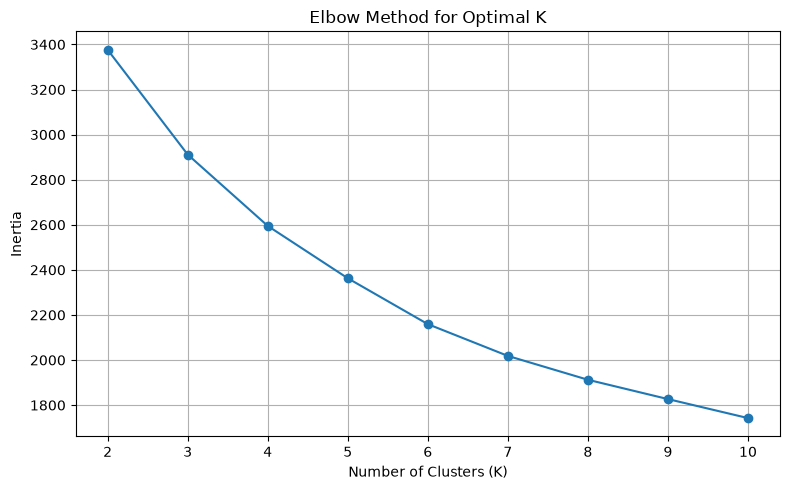

Elbow Method graph created successfully!


In [8]:
# Elbow Method visualization

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results["Clusters"],
    cluster_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(cluster_results["Clusters"])
plt.grid(True)

plt.tight_layout()
plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

print("Elbow Method graph created successfully!")

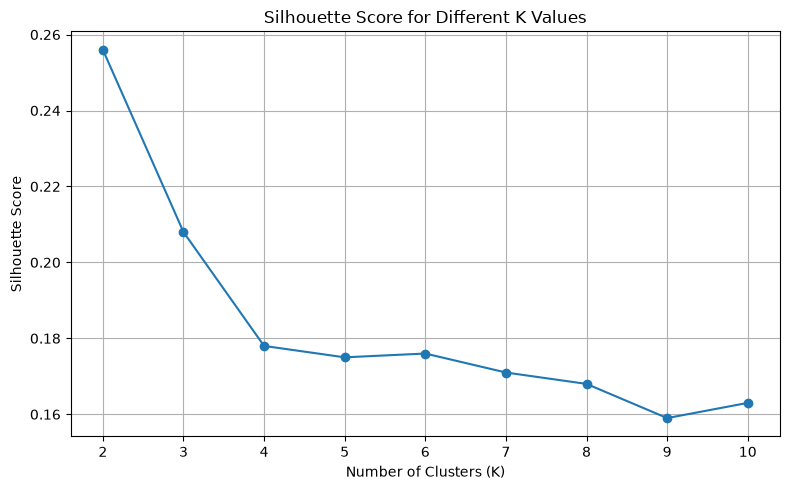

Silhouette Score graph created successfully!


In [9]:
# Silhouette Score visualization

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results["Clusters"],
    cluster_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(cluster_results["Clusters"])
plt.grid(True)

plt.tight_layout()
plt.savefig("silhouette_scores.png", dpi=300, bbox_inches="tight")

plt.show()

print("Silhouette Score graph created successfully!")

In [10]:
# Find the K value with the highest Silhouette Score

best_silhouette_index = cluster_results["Silhouette Score"].idxmax()

best_silhouette_k = int(
    cluster_results.loc[best_silhouette_index, "Clusters"]
)

best_silhouette_score = (
    cluster_results.loc[
        best_silhouette_index,
        "Silhouette Score"
    ]
)

best_silhouette_inertia = (
    cluster_results.loc[
        best_silhouette_index,
        "Inertia"
    ]
)

print("========== SILHOUETTE ANALYSIS ==========")
print("Best K based on Silhouette Score:", best_silhouette_k)
print("Highest Silhouette Score:", best_silhouette_score)
print("Corresponding Inertia:", best_silhouette_inertia)

========== SILHOUETTE ANALYSIS ==========
Best K based on Silhouette Score: 2
Highest Silhouette Score: 0.256
Corresponding Inertia: 3376.46


In [11]:
# Select the final K based on Silhouette Score

final_k = best_silhouette_k

print("========== FINAL CLUSTER SELECTION ==========")
print("Selected K:", final_k)
print("Reason: It has the highest Silhouette Score.")
print("Silhouette Score:", best_silhouette_score)

print("\nThe Elbow Method will be used as a visual confirmation.")

========== FINAL CLUSTER SELECTION ==========
Selected K: 2
Reason: It has the highest Silhouette Score.
Silhouette Score: 0.256

The Elbow Method will be used as a visual confirmation.


In [12]:
# Apply final K-Means clustering

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

customer_data["cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final customer segmentation completed successfully!")

print("\nNumber of customers in each cluster:")
print(customer_data["cluster"].value_counts().sort_index())

print("\nSample customer segments:")
display(customer_data.head())

Final customer segmentation completed successfully!

Number of customers in each cluster:
cluster
0    338
1    457
Name: count, dtype: int64

Sample customer segments:


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,cluster
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89,0
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56,0
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60,1
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68,0
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84,0


In [13]:
# Create customer segment profiles

segment_profile = customer_data.groupby("cluster")[feature_columns].mean().round(2)

segment_profile["customer_count"] = (
    customer_data.groupby("cluster").size()
)

print("Customer segment profiles created successfully!")

display(segment_profile)

Customer segment profiles created successfully!


,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,customer_count
cluster,,,,,,,
0,20109.22,267.53,2616.06,0.14,3.95,75.81,338
1,12792.09,192.31,1279.66,0.15,3.99,56.16,457


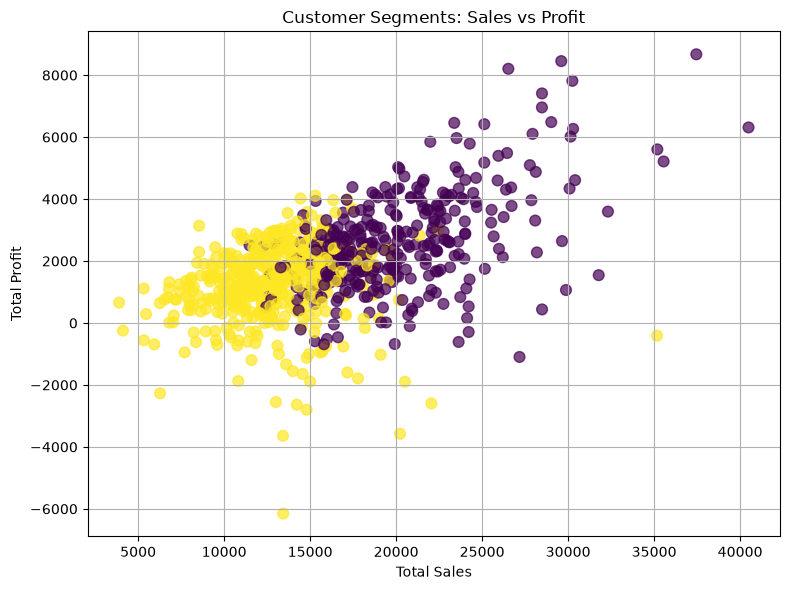

Customer segment visualization created successfully!


In [14]:
# Visualize the final customer segments

plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data["total_sales"],
    customer_data["total_profit"],
    c=customer_data["cluster"],
    cmap="viridis",
    s=60,
    alpha=0.7
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.title("Customer Segments: Sales vs Profit")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "customer_segments_day30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Customer segment visualization created successfully!")

In [15]:
# Display detailed profiles of the two customer segments

print("========== CUSTOMER SEGMENT PROFILES ==========\n")

for cluster in segment_profile.index:

    print(f"Cluster {cluster}")
    print("-" * 40)

    print("Customers:", segment_profile.loc[cluster, "customer_count"])
    print("Average Sales:", segment_profile.loc[cluster, "total_sales"])
    print("Average Quantity:", segment_profile.loc[cluster, "total_quantity"])
    print("Average Profit:", segment_profile.loc[cluster, "total_profit"])
    print("Average Discount:", segment_profile.loc[cluster, "average_discount"])
    print("Average Shipping Days:", segment_profile.loc[cluster, "average_shipping_days"])
    print("Average Number of Orders:", segment_profile.loc[cluster, "number_of_orders"])

    print()

========== CUSTOMER SEGMENT PROFILES ==========

Cluster 0
----------------------------------------
Customers: 338
Average Sales: 20109.22
Average Quantity: 267.53
Average Profit: 2616.06
Average Discount: 0.14
Average Shipping Days: 3.95
Average Number of Orders: 75.81

Cluster 1
----------------------------------------
Customers: 457
Average Sales: 12792.09
Average Quantity: 192.31
Average Profit: 1279.66
Average Discount: 0.15
Average Shipping Days: 3.99
Average Number of Orders: 56.16



In [16]:
# Compare the two customer segments

comparison = segment_profile[
    [
        "total_sales",
        "total_quantity",
        "total_profit",
        "average_discount",
        "average_shipping_days",
        "number_of_orders",
        "customer_count"
    ]
]

print("========== SEGMENT COMPARISON ==========\n")
display(comparison)

print("Compare Cluster 0 and Cluster 1 using the values above.")

========== SEGMENT COMPARISON ==========



,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,customer_count
cluster,,,,,,,
0,20109.22,267.53,2616.06,0.14,3.95,75.81,338
1,12792.09,192.31,1279.66,0.15,3.99,56.16,457


Compare Cluster 0 and Cluster 1 using the values above.


In [17]:
# Assign business-friendly names to the customer segments

high_value_cluster = segment_profile["total_sales"].idxmax()

customer_data["segment_name"] = np.where(
    customer_data["cluster"] == high_value_cluster,
    "High-Value Customers",
    "Regular Customers"
)

print("Business segment names assigned successfully!")

print("\nSegment distribution:")
print(customer_data["segment_name"].value_counts())

print("\nSample customer segments:")
display(
    customer_data[
        ["customer_name", "cluster", "segment_name"]
    ].head(10)
)

Business segment names assigned successfully!

Segment distribution:
segment_name
Regular Customers       457
High-Value Customers    338
Name: count, dtype: int64

Sample customer segments:


,customer_name,cluster,segment_name
0,Aaron Bergman,0,High-Value Customers
1,Aaron Hawkins,0,High-Value Customers
2,Aaron Smayling,1,Regular Customers
3,Adam Bellavance,0,High-Value Customers
4,Adam Hart,0,High-Value Customers
5,Adam Shillingsburg,0,High-Value Customers
6,Adrian Barton,0,High-Value Customers
7,Adrian Hane,1,Regular Customers
8,Adrian Shami,1,Regular Customers
9,Aimee Bixby,1,Regular Customers


In [18]:
# Create the final business segmentation strategy

strategy = {
    "High-Value Customers": {
        "Focus": "Customer retention and loyalty",
        "Action": "Offer loyalty rewards, personalized offers, and priority service",
        "Goal": "Increase retention and maintain strong customer relationships"
    },
    
    "Regular Customers": {
        "Focus": "Customer engagement and growth",
        "Action": "Use targeted promotions and product recommendations",
        "Goal": "Encourage more purchases and increase customer value"
    }
}

print("========== FINAL BUSINESS SEGMENTATION STRATEGY ==========\n")

for segment, details in strategy.items():
    
    print(segment)
    print("-" * 50)
    print("Focus :", details["Focus"])
    print("Action:", details["Action"])
    print("Goal  :", details["Goal"])
    print()

========== FINAL BUSINESS SEGMENTATION STRATEGY ==========

High-Value Customers
--------------------------------------------------
Focus : Customer retention and loyalty
Action: Offer loyalty rewards, personalized offers, and priority service
Goal  : Increase retention and maintain strong customer relationships

Regular Customers
--------------------------------------------------
Focus : Customer engagement and growth
Action: Use targeted promotions and product recommendations
Goal  : Encourage more purchases and increase customer value



In [19]:
# Save Day 30 results

cluster_results.to_csv(
    "cluster_optimization_results.csv",
    index=False
)

segment_profile.to_csv(
    "customer_segment_profiles.csv"
)

customer_data.to_csv(
    "customer_segments_final.csv",
    index=False
)

print("Day 30 result files saved successfully!")

print("\nFiles created:")
print("1. cluster_optimization_results.csv")
print("2. customer_segment_profiles.csv")
print("3. customer_segments_final.csv")
print("4. elbow_method.png")
print("5. silhouette_scores.png")
print("6. customer_segments_day30.png")

Day 30 result files saved successfully!

Files created:
1. cluster_optimization_results.csv
2. customer_segment_profiles.csv
3. customer_segments_final.csv
4. elbow_method.png
5. silhouette_scores.png
6. customer_segments_day30.png


In [20]:
# Create Day 30 segmentation strategy report

high_value_cluster = int(
    segment_profile["total_sales"].idxmax()
)

regular_cluster = [
    int(c) for c in segment_profile.index
    if c != high_value_cluster
][0]

high_value_customers = int(
    segment_profile.loc[
        high_value_cluster,
        "customer_count"
    ]
)

regular_customers = int(
    segment_profile.loc[
        regular_cluster,
        "customer_count"
    ]
)

report = f"""# Day 30 - Customer Segmentation Strategy

## Objective

The objective of Day 30 was to identify the ideal number of customer segments
using clustering optimization techniques.

## Methods Used

- Elbow Method
- Silhouette Score
- K-Means Clustering
- Customer behavior analysis

## K Values Tested

K values from 2 to 10 were tested.

The Elbow Method was used to study the reduction in inertia,
while the Silhouette Score was used to evaluate cluster separation.

## Final Segmentation

The final model contains **{final_k} customer segments**.

### High-Value Customers

- Cluster: {high_value_cluster}
- Number of customers: {high_value_customers}
- Business focus: Customer retention and loyalty
- Recommended action: Loyalty rewards, personalized offers, and priority service

### Regular Customers

- Cluster: {regular_cluster}
- Number of customers: {regular_customers}
- Business focus: Customer engagement and growth
- Recommended action: Targeted promotions and product recommendations

## Business Strategy

The clustering results can help a business understand different customer
behavior patterns and design appropriate strategies for each segment.

High-value customers should receive retention-focused strategies,
while regular customers can be encouraged to increase their purchase
frequency and overall customer value.

## Conclusion

K-Means clustering combined with the Elbow Method and Silhouette Score
provided a structured approach to customer segmentation.

The final segmentation converts customer behavior data into
actionable business insights.
"""

with open("segmentation_strategy.md", "w", encoding="utf-8") as file:
    file.write(report)

print("Segmentation strategy report created successfully!")
print("File: segmentation_strategy.md")

Segmentation strategy report created successfully!
File: segmentation_strategy.md


In [21]:
# Check Day 30 output files

import os

files = [
    "day30.ipynb",
    "elbow_method.png",
    "silhouette_scores.png",
    "customer_segments_day30.png",
    "cluster_optimization_results.csv",
    "customer_segment_profiles.csv",
    "customer_segments_final.csv",
    "segmentation_strategy.md",
    "README.md"
]

print("========== DAY 30 FILE CHECK ==========\n")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file, "NOT FOUND")

========== DAY 30 FILE CHECK ==========

✅ day30.ipynb
✅ elbow_method.png
✅ silhouette_scores.png
✅ customer_segments_day30.png
✅ cluster_optimization_results.csv
✅ customer_segment_profiles.csv
✅ customer_segments_final.csv
✅ segmentation_strategy.md
✅ README.md
